# Stage 2-3a — Classical Baseline: HOG + SVM

**Purpose**: Train and evaluate the classical baseline pipeline on the `metal_nut` category.

**Pipeline**: `preprocess()` → `extract_hog()` → `ClassicalClassifier (SVM+RBF)`

**What this notebook covers**:
1. Dataset loading and train/test split strategy
2. HOG feature extraction and visualization
3. SVM training
4. Evaluation: accuracy, F1, confusion matrix
5. Design decisions and their rationale

---

### Dataset split strategy

MVTec provides defective images only in the test split. To train a supervised binary classifier we need both classes in the training data. Strategy: **combine all available images** (train/good + test/good + test/defective) and apply a stratified 70/30 split. This ensures both classes are proportionally represented in train and test.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from skimage.feature import hog as skimage_hog
import time
import warnings
warnings.filterwarnings('ignore')

from src.preprocessing import preprocess
from src.features import extract_hog, HOG_ORIENTATIONS, HOG_PIXELS_PER_CELL, HOG_CELLS_PER_BLOCK
from src.models.classical import ClassicalClassifier

RANDOM_STATE = 42  # fixed seed for reproducibility
CATEGORY     = 'metal_nut'
DATA_ROOT    = Path('../data/mvtec_ad')

print('Imports OK')
print(f'HOG params: orientations={HOG_ORIENTATIONS}, pixels_per_cell={HOG_PIXELS_PER_CELL}, cells_per_block={HOG_CELLS_PER_BLOCK}')

Imports OK
HOG params: orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2)


## 1. Load all images

In [2]:
def load_split(folder: Path, label: int) -> tuple:
    """Load all images from a folder, preprocess, return (paths, arrays, labels)."""
    paths, images, labels = [], [], []
    for p in sorted(folder.glob('*.png')):
        img = preprocess(str(p))
        images.append(img)
        labels.append(label)
        paths.append(str(p))
    return paths, images, labels

category_path = DATA_ROOT / CATEGORY
all_paths, all_images, all_labels = [], [], []

# good images (label 0): train/good + test/good
for folder in [category_path / 'train' / 'good', category_path / 'test' / 'good']:
    p, imgs, lbls = load_split(folder, label=0)
    all_paths += p; all_images += imgs; all_labels += lbls

# defective images (label 1): all subfolders in test/ except good
for subfolder in sorted((category_path / 'test').iterdir()):
    if subfolder.is_dir() and subfolder.name != 'good':
        p, imgs, lbls = load_split(subfolder, label=1)
        all_paths += p; all_images += imgs; all_labels += lbls

all_labels = np.array(all_labels)
n_good     = (all_labels == 0).sum()
n_defect   = (all_labels == 1).sum()

print(f'Total images loaded: {len(all_images)}')
print(f'  Good (0):      {n_good}')
print(f'  Defective (1): {n_defect}')

Total images loaded: 335
  Good (0):      242
  Defective (1): 93


## 2. HOG feature extraction

In [3]:
t0 = time.time()
X = np.array([extract_hog(img) for img in all_images])
elapsed = time.time() - t0

print(f'Feature matrix shape: {X.shape}  ({X.shape[0]} samples × {X.shape[1]} features)')
print(f'Extraction time: {elapsed:.1f}s  ({elapsed/len(all_images)*1000:.1f} ms/image)')
print(f'Feature range: [{X.min():.4f}, {X.max():.4f}]')

Feature matrix shape: (335, 26244)  (335 samples × 26244 features)
Extraction time: 3.1s  (9.2 ms/image)
Feature range: [0.0000, 0.9963]


## 3. Visualize HOG on a sample image

The HOG visualization shows the dominant gradient direction in each cell as an oriented line. Dense, uniform lines → smooth surface. Irregular or disrupted lines → potential defect region.

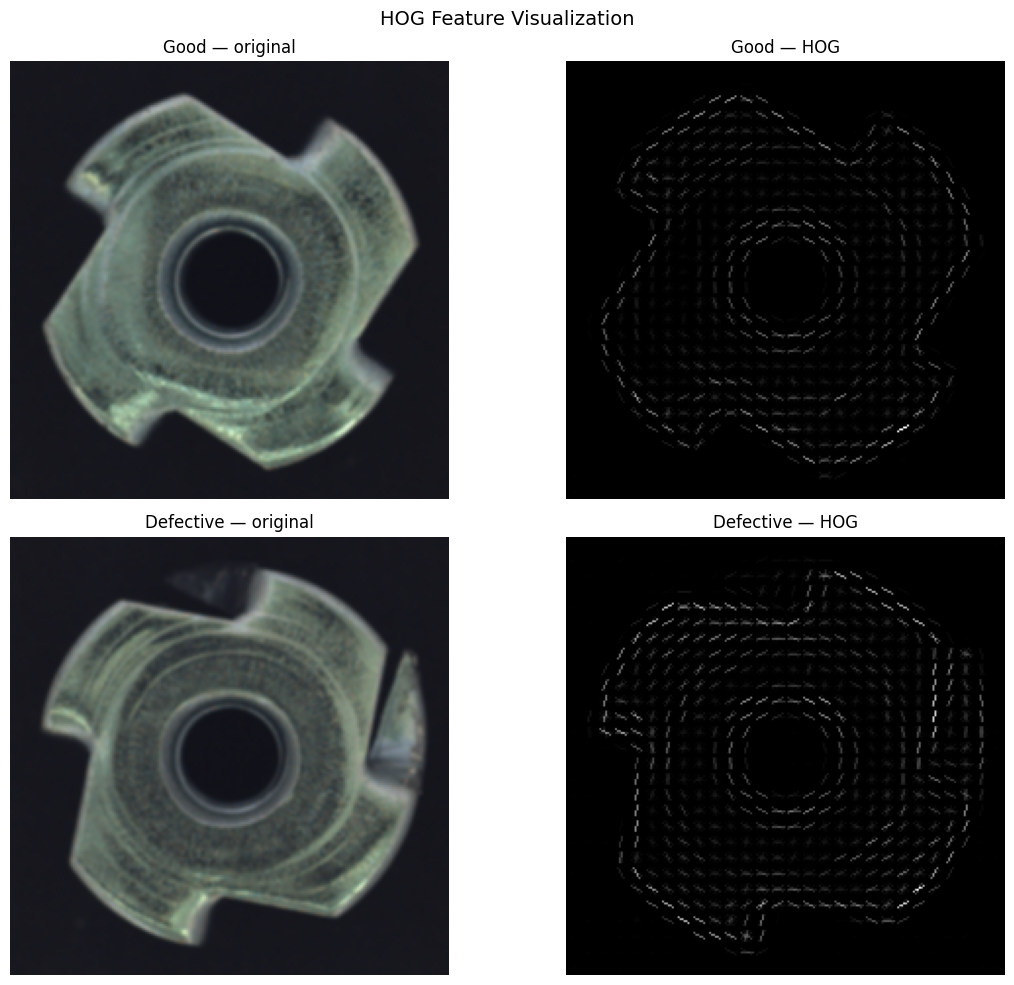

In [4]:
import cv2
from skimage.feature import hog as skimage_hog

def hog_visualization(image: np.ndarray) -> np.ndarray:
    """Return HOG visualization array for display."""
    gray = cv2.cvtColor((image * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    _, hog_img = skimage_hog(
        gray,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        visualize=True, feature_vector=True
    )
    return hog_img

# Pick one good and one defective sample
good_idx   = np.where(all_labels == 0)[0][0]
defect_idx = np.where(all_labels == 1)[0][0]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for row, idx, title in [(0, good_idx, 'Good'), (1, defect_idx, 'Defective')]:
    img     = all_images[idx]
    hog_img = hog_visualization(img)
    axes[row, 0].imshow(img);     axes[row, 0].set_title(f'{title} — original')
    axes[row, 1].imshow(hog_img, cmap='gray'); axes[row, 1].set_title(f'{title} — HOG')
    for ax in axes[row]: ax.axis('off')

plt.suptitle('HOG Feature Visualization', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Train/test split and SVM training

**Why stratified split**: the dataset is imbalanced (more good than defective). A stratified split preserves the class ratio in both train and test sets, preventing a situation where all defective samples end up in one split.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, all_labels,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=all_labels
)

print(f'Train: {X_train.shape[0]} samples  (good: {(y_train==0).sum()}, defective: {(y_train==1).sum()})')
print(f'Test:  {X_test.shape[0]}  samples  (good: {(y_test==0).sum()}, defective: {(y_test==1).sum()})')

clf = ClassicalClassifier()

t0 = time.time()
clf.fit(X_train, y_train)
print(f'\nSVM training time: {time.time() - t0:.1f}s')

Train: 234 samples  (good: 169, defective: 65)
Test:  101  samples  (good: 73, defective: 28)

SVM training time: 34.1s


## 5. Evaluation

In [6]:
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='binary')
cm  = confusion_matrix(y_test, y_pred)

print('=== HOG + SVM Baseline Results ===')
print(f'Accuracy : {acc:.4f} ({acc*100:.1f}%)')
print(f'F1-score : {f1:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['good', 'defective']))

=== HOG + SVM Baseline Results ===
Accuracy : 0.8317 (83.2%)
F1-score : 0.6047

              precision    recall  f1-score   support

        good       0.83      0.97      0.89        73
   defective       0.87      0.46      0.60        28

    accuracy                           0.83       101
   macro avg       0.85      0.72      0.75       101
weighted avg       0.84      0.83      0.81       101



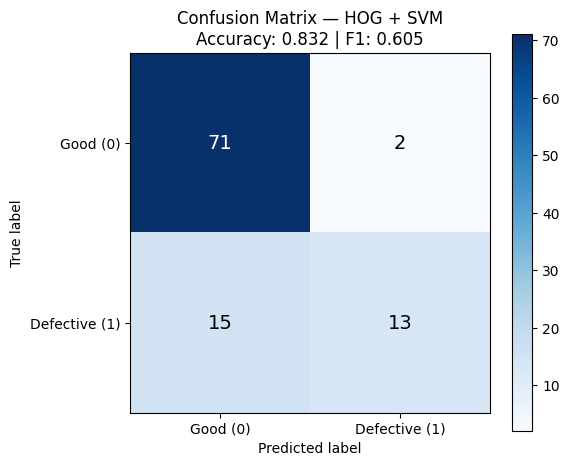

True Negatives  (good correctly classified):     71
False Positives (good classified as defective):  2
False Negatives (defect missed):                 15  ← safety-critical
True Positives  (defect correctly detected):     13


In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

classes = ['Good (0)', 'Defective (1)']
ax.set_xticks([0, 1]); ax.set_xticklabels(classes)
ax.set_yticks([0, 1]); ax.set_yticklabels(classes)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title(f'Confusion Matrix — HOG + SVM\nAccuracy: {acc:.3f} | F1: {f1:.3f}')

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (good correctly classified):     {tn}')
print(f'False Positives (good classified as defective):  {fp}')
print(f'False Negatives (defect missed):                 {fn}  ← safety-critical')
print(f'True Positives  (defect correctly detected):     {tp}')

## 6. Summary — Design Decisions

| Choice | Value | Why |
|---|---|---|
| Features | HOG | Captures gradient structure; robust to illumination; fast |
| Orientations | 9 | Standard (Dalal & Triggs 2005); 40° resolution per bin |
| Pixels per cell | 8×8 | Balances spatial resolution vs vector length on 224×224 |
| Cells per block | 2×2 | Local L2 normalization improves contrast invariance |
| Classifier | SVM RBF | Best classical method on high-dim dense vectors |
| C | 1.0 | Default regularization; tune if F1 < 0.80 |
| Scaling | StandardScaler | Mandatory — SVM optimization is scale-sensitive |
| Split strategy | Stratified 70/30 | MVTec has no train/defective; combines all images |

**Baseline role**: this result is the lower bound. The EfficientNet model (Commit 6) is expected to exceed this F1 by learning richer, data-driven features.